# Evaluation intermédiaire Python pour la data science.


## Librairie utilisée

In [2]:
! pip install pandas -q
! pip install matplotlib -q
! pip install cartiflette -q
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from cartiflette import carti_download



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Données du projet

In [22]:
elections = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'  
)
elections.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31112\992122100.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  elections = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [24]:
#Nombre de lignes et de colonnes
print(f"La base de données contient {elections.shape[0]} lignes et {elections.shape[1]} colonnes.")
#Liste des colonnes
print("Les colonnes de la base de données sont :")
for col in elections.columns:
    print(f"- {col}")
#Types de données
print("\nTypes de données :")
print(elections.dtypes)


La base de données contient 528675 lignes et 7 colonnes.
Les colonnes de la base de données sont :
- code_departement
- libelle_departement
- code_commune
- libelle_commune
- prenom
- nom
- voix

Types de données :
code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object


# 1. Explorations générales

### Question 1: Création et mise à jour des variables

In [25]:
# code_commune : on concatène le code département (2 chiffres) et le code commune (3 chiffres)
elections['code_commune'] = (
    elections['code_departement'].astype(str).str.zfill(2)
    + elections['code_commune'].astype(str).str.zfill(3)
)

# candidat : prénom + nom
elections['candidat'] = elections['prenom'].astype(str) + ' ' + elections['nom'].astype(str)

elections[['code_commune', 'libelle_commune', 'candidat', 'voix']].head()

,code_commune,libelle_commune,candidat,voix
0,01001,L'Abergement-Clémenciat,Nathalie ARTHAUD,3
1,01002,L'Abergement-de-Varey,Nathalie ARTHAUD,2
2,01004,Ambérieu-en-Bugey,Nathalie ARTHAUD,38
3,01005,Ambérieux-en-Dombes,Nathalie ARTHAUD,8
4,01006,Ambléon,Nathalie ARTHAUD,0


### Question 2: Mise en forme


In [27]:
# Exclusion des lignes non-candidats (abstentions, blancs, nuls)
non_candidats = ['NAN ABSTENTIONS', 'NAN BLANCS', 'NAN NULS']
masque_candidats = ~elections['candidat'].str.upper().isin(non_candidats)

candidats = elections[masque_candidats]['candidat'].nunique()

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")
print("Liste des candidats :")
for candidat in sorted(elections[masque_candidats]['candidat'].unique()):
    print(candidat)

En 2022, il y avait 12 candidats à l'élection présidentielle.
Liste des candidats :
Anne HIDALGO
Emmanuel MACRON
Fabien ROUSSEL
Jean LASSALLE
Jean-Luc MÉLENCHON
Marine LE PEN
Nathalie ARTHAUD
Nicolas DUPONT-AIGNAN
Philippe POUTOU
Valérie PÉCRESSE
Yannick JADOT
Éric ZEMMOUR


### Question 3: Scores nationaux de chaque candidat

In [ ]:
# Votes exprimés uniquement (on exclut les non-candidats)
elections_candidats = elections[masque_candidats].copy()

# Scores nationaux
score_national = elections_candidats.groupby('candidat', as_index=False)['voix'].sum()
total_exprime = score_national['voix'].sum()

score_national = (
    elections_candidats
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_national'})
    .sort_values('votes_national', ascending=False)
    .reset_index(drop=True)
)

score_national['score_national'] = score_national['votes_national'] / total_exprime * 100

# Affichage 
display_elections = score_national.copy()
display_elections['votes_national'] = display_elections['votes_national'].apply(lambda x: f"{x:,.0f}".replace(',', ' '))
display_elections['score_national'] = display_elections['score_national'].apply(lambda x: f"{x:.2f}%")
display_elections.index += 1  

print("\n Résultats du 1er tour aux élections présidentielles de 2022: \n")
display_elections


 Résultats du 1er tour du 10 avril 2022: 



,candidat,votes_national,score_national
1,Emmanuel MACRON,9 783 058,27.85%
2,Marine LE PEN,8 133 828,23.15%
3,Jean-Luc MÉLENCHON,7 712 520,21.95%
4,Éric ZEMMOUR,2 485 226,7.07%
5,Valérie PÉCRESSE,1 679 001,4.78%
6,Yannick JADOT,1 627 853,4.63%
7,Jean LASSALLE,1 101 387,3.13%
8,Fabien ROUSSEL,802 422,2.28%
9,Nicolas DUPONT-AIGNAN,725 176,2.06%
10,Anne HIDALGO,616 478,1.75%


On constate que les 2 candidats arrivés en tête sont Emmanuel Macron et Marine Le Pen, avec respectivement 27.84% et 23.15% des voix exprimées. Ils se sont donc qualifiés pour le second tour.


# 2. Comparaison des scores départements aux moyennes nationales.

### Question 4: Création du dataframe nommé score_departements

In [30]:
elelections_candidats =elections[masque_candidats].copy()

# Somme des voix par département et candidat
votes_dep = (
   elections_candidats
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_departement'})
)

# Total des votes exprimés par département
total_dep = (
    votes_dep.groupby('code_departement', as_index=False)['votes_departement']
    .sum()
    .rename(columns={'votes_departement': 'total_dep'})
)

# Calcul du pourcentage par department
score_departements = votes_dep.merge(total_dep, on='code_departement')
score_departements['score_departement'] = score_departements['votes_departement'] / score_departements['total_dep'] * 100
score_departements = score_departements.sort_values(['code_departement', 'votes_departement'], ascending=[True, False])

# Vérification pour le département 11
aude = score_departements[score_departements['code_departement'] == '11'].copy()
aude['score_departement'] = aude['score_departement'].apply(lambda x: f"{x:.2f}%")
display(aude)

,code_departement,candidat,votes_departement,total_dep,score_departement
125,11,Marine LE PEN,64027,212426,30.14%
121,11,Emmanuel MACRON,43104,212426,20.29%
124,11,Jean-Luc MÉLENCHON,42039,212426,19.79%
131,11,Éric ZEMMOUR,18434,212426,8.68%
123,11,Jean LASSALLE,12382,212426,5.83%
129,11,Valérie PÉCRESSE,7350,212426,3.46%
130,11,Yannick JADOT,6322,212426,2.98%
120,11,Anne HIDALGO,6166,212426,2.90%
122,11,Fabien ROUSSEL,5622,212426,2.65%
127,11,Nicolas DUPONT-AIGNAN,4206,212426,1.98%


###  Question 5 – Jointure avec le niveau national pour comparaison

In [31]:
score_departements = score_departements.merge(
    score_national[['candidat', 'votes_national', 'score_national']],
    on='candidat'
)

# Vérification pour l'Aude
print(" Vérification pour le département 11 (Aude) – 3 premiers candidats :")
check = score_departements[score_departements['code_departement'] == '11'].head(3).copy()
check['score_departement'] = check['score_departement'].apply(lambda x: f"{x:.2f}%")
check['score_national'] = check['score_national'].apply(lambda x: f"{x:.2f}%")
check

 Vérification pour le département 11 (Aude) – 3 premiers candidats :


,code_departement,candidat,votes_departement,total_dep,score_departement,votes_national,score_national
120,11,Marine LE PEN,64027,212426,30.14%,8133828,23.15%
121,11,Emmanuel MACRON,43104,212426,20.29%,9783058,27.85%
122,11,Jean-Luc MÉLENCHON,42039,212426,19.79%,7712520,21.95%


###  Question 6 : Création de la Variable `surrepresentation`

In [32]:
# surrepresentation = (score_dep - score_national) / score_national * 100
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)


print("Exemple (dept 11, Marine Le Pen) :",
      round(score_departements[
          (score_departements['code_departement'] == '11') &
          (score_departements['candidat'] == 'Marine LE PEN')
      ]['surrepresentation'].values[0], 2), "%")

score_departements.head()

Exemple (dept 11, Marine Le Pen) : 30.19 %


,code_departement,candidat,votes_departement,total_dep,score_departement,votes_national,score_national,surrepresentation
0,01,Emmanuel MACRON,92206,333024,27.687494,9783058,27.845822,-0.568589
1,01,Marine LE PEN,86755,333024,26.050675,8133828,23.151568,12.522294
2,01,Jean-Luc MÉLENCHON,57832,333024,17.365715,7712520,21.952386,-20.893721
3,01,Éric ZEMMOUR,27530,333024,8.266671,2485226,7.073776,16.863630
4,01,Valérie PÉCRESSE,17572,333024,5.276497,1679001,4.778993,10.410223


###  Question 7 – Visualisation des surreprésentations

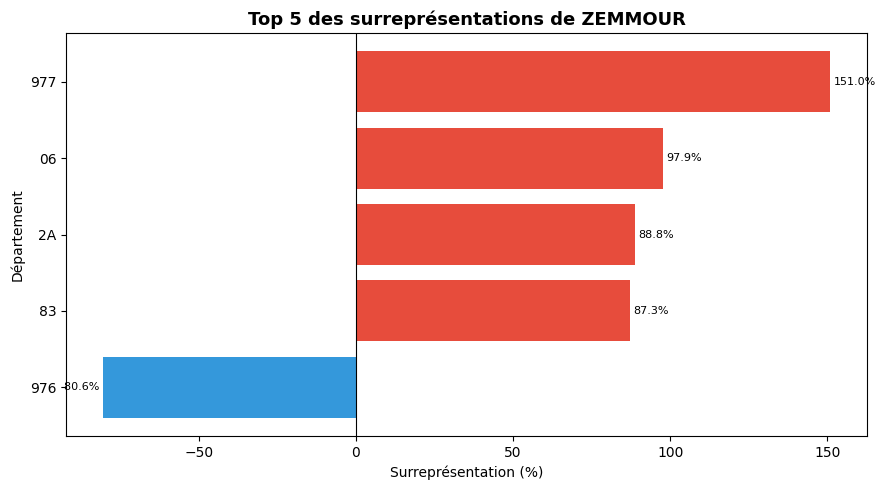

In [33]:
def plot_surrepresentation(candidat_nom, score_departements, top_n=10):
    
    data = score_departements[score_departements['candidat'] == candidat_nom].copy()
    
    if data.empty:
        print(f"Candidat '{candidat_nom}' introuvable.")
        return
    
    # Top N en valeur absolue
    top = (
        data.reindex(data['surrepresentation'].abs().sort_values(ascending=False).index)
        .head(top_n)
        .sort_values('surrepresentation')
    )
    
    nom_court = candidat_nom.split()[-1]  
    
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e74c3c' if v >= 0 else '#3498db' for v in top['surrepresentation']]
    
    ax.barh(top['code_departement'].astype(str), top['surrepresentation'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation (%)')
    ax.set_ylabel('Département')
    ax.set_title(f'Top {top_n} des surreprésentations de {nom_court}', fontsize=13, fontweight='bold')
    
    # Annotations valeurs
    for i, (val, dep) in enumerate(zip(top['surrepresentation'], top['code_departement'])):
        ha = 'left' if val >= 0 else 'right'
        offset = 1 if val >= 0 else -1
        ax.text(val + offset, i, f"{val:.1f}%", va='center', ha=ha, fontsize=8)
    
    plt.tight_layout()
    plt.show()


# Test sur Éric Zemmour
plot_surrepresentation('Éric ZEMMOUR', score_departements, top_n=5)

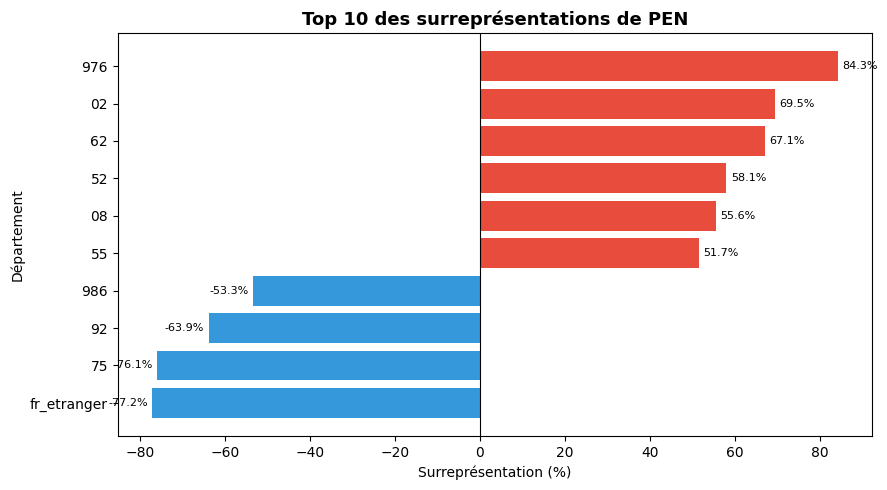

In [34]:
# Test sur Marine Le Pen
plot_surrepresentation('Marine LE PEN', score_departements, top_n=10)

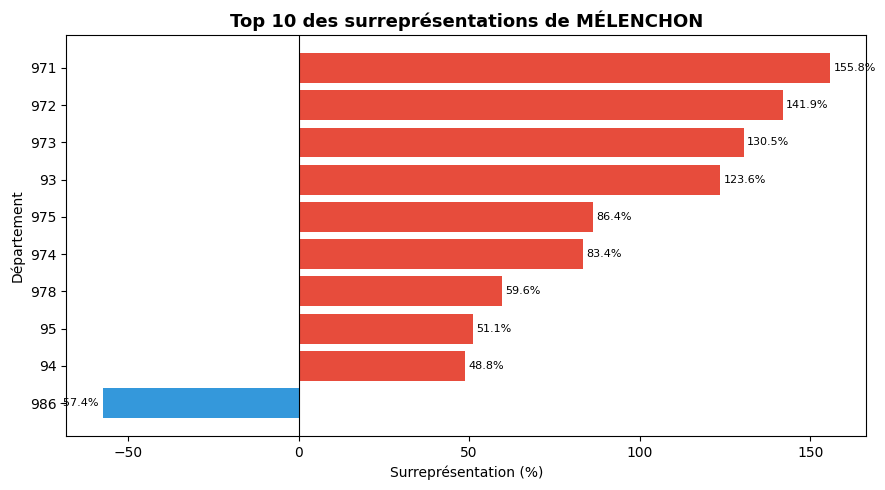

In [35]:
# Test sur Jean-Luc Mélenchon
plot_surrepresentation('Jean-Luc MÉLENCHON', score_departements, top_n=10)

## 3. Cartographie

In [36]:
# Téléchargement du fond de carte
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

### Question 8: Fonction permettant de restreindre le score_departements par candidat

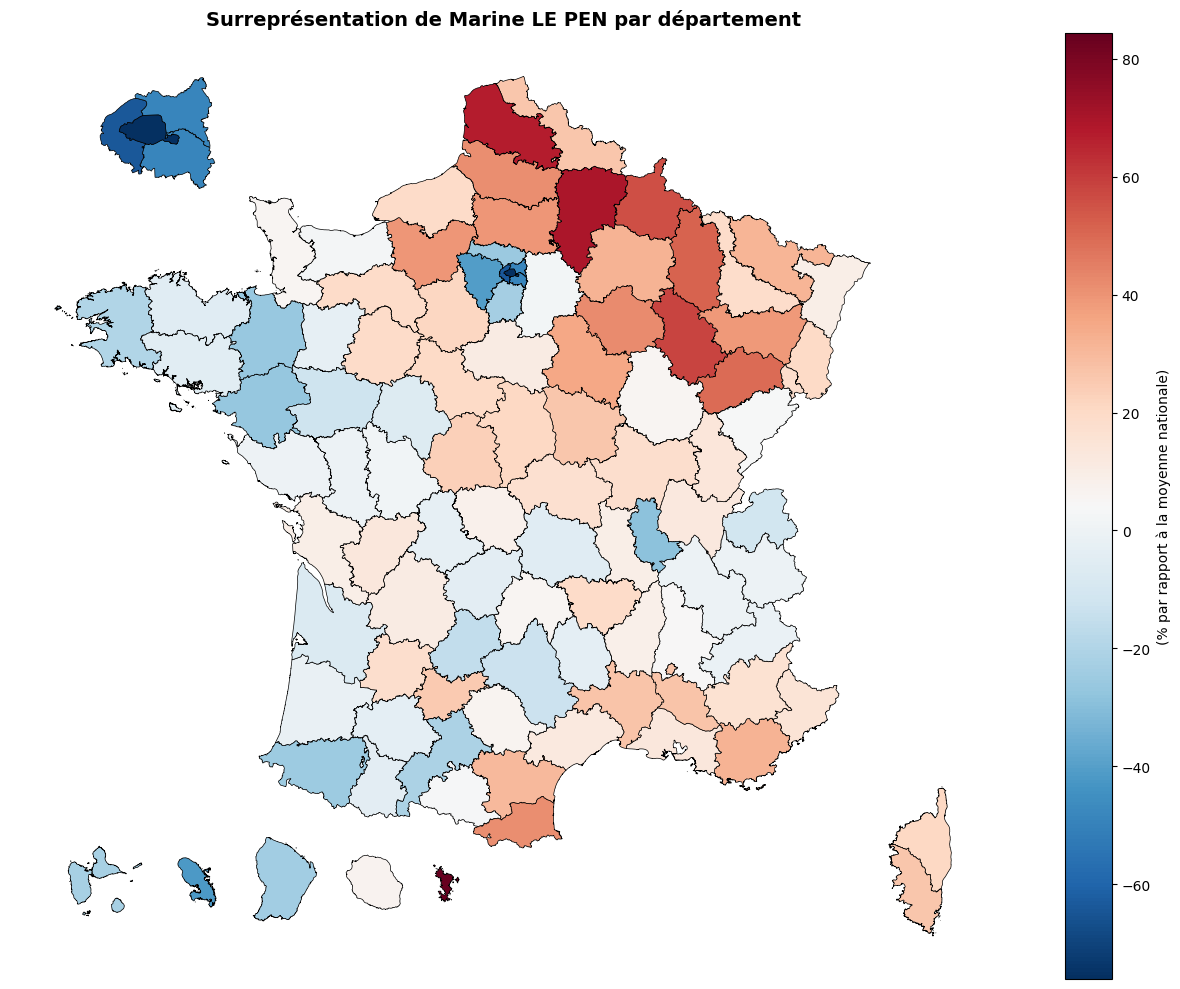

In [37]:
def get_candidate_data(candidat_nom, score_departements):
    """
    Restreint les données score_departements pour un candidat spécifique.
    
    Paramètress:
    - candidat_nom: nom du candidat
    - score_departements: dataframe avec tous les scores
    
    sortie:
    - dataframe filtrée pour le candidat
    """
    return score_departements[score_departements['candidat'] == candidat_nom].copy()


# Test sur Marine Le Pen
marine_data = get_candidate_data('Marine LE PEN', score_departements)

# Convertir le geojson en GeoDataFrame
gdf_departments = departement_borders.copy()
gdf_departments['code'] = gdf_departments['INSEE_DEP'].astype(str).str.zfill(2)

# On merge les données avec le fond de carte
marine_map = gdf_departments.merge(
    marine_data,
    left_on='code',
    right_on='code_departement',
    how='left'
)

# Création de la carte
fig, ax = plt.subplots(figsize=(14, 10))
marine_map.plot(
    column='surrepresentation',
    ax=ax,
    legend=True,
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': '(% par rapport à la moyenne nationale)', 'orientation': 'vertical'}
)
ax.set_title('Surreprésentation de Marine LE PEN par département', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

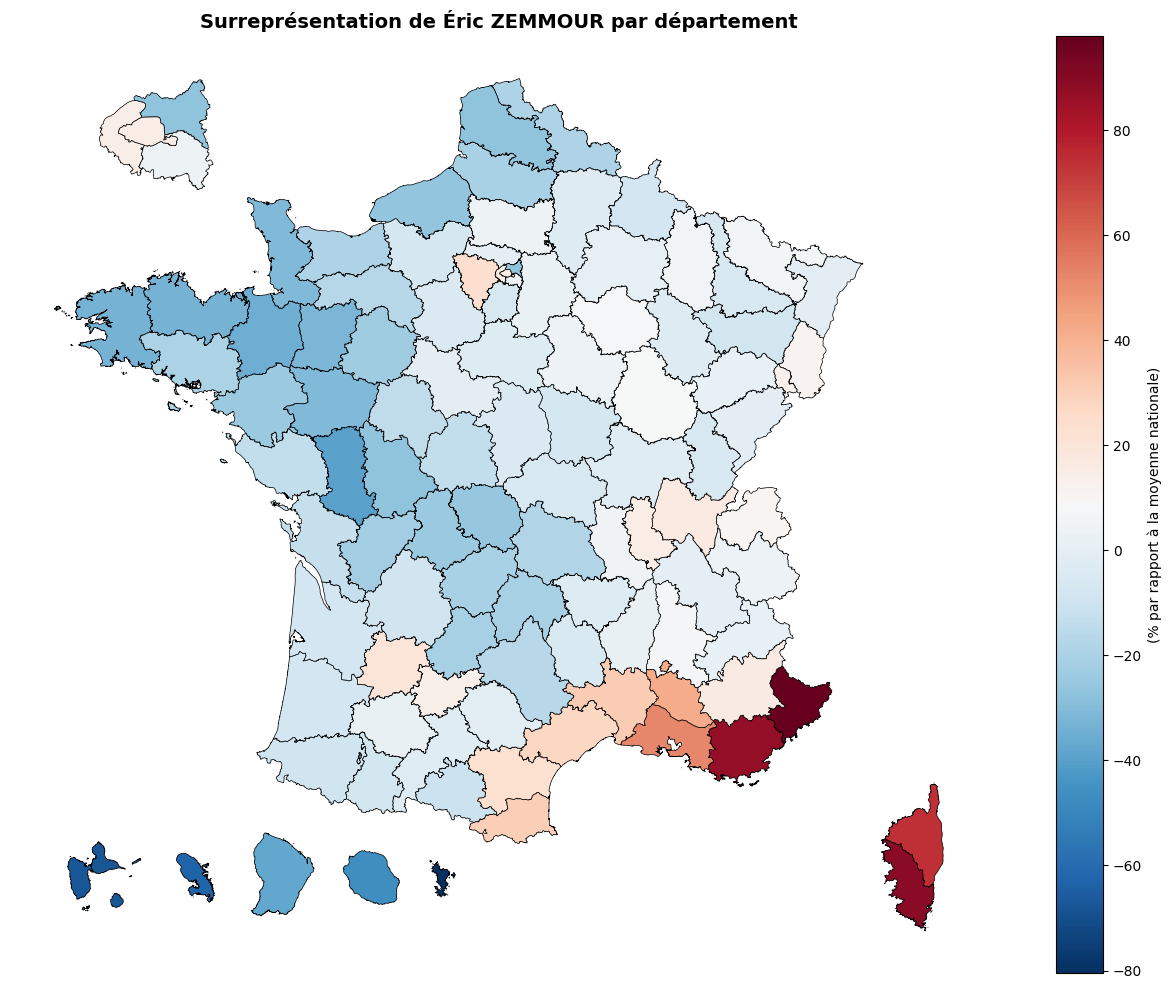

In [38]:
#test sur Éric Zemmour
zemmour_data = get_candidate_data('Éric ZEMMOUR', score_departements)
zemmour_map = gdf_departments.merge(
    zemmour_data,
    left_on='code',
    right_on='code_departement',
    how='left'
)
fig, ax = plt.subplots(figsize=(14, 10))
zemmour_map.plot(
    column='surrepresentation',
    ax=ax,
    legend=True,
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': '(% par rapport à la moyenne nationale)', 'orientation': 'vertical'}
)
ax.set_title('Surreprésentation de Éric ZEMMOUR par département', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

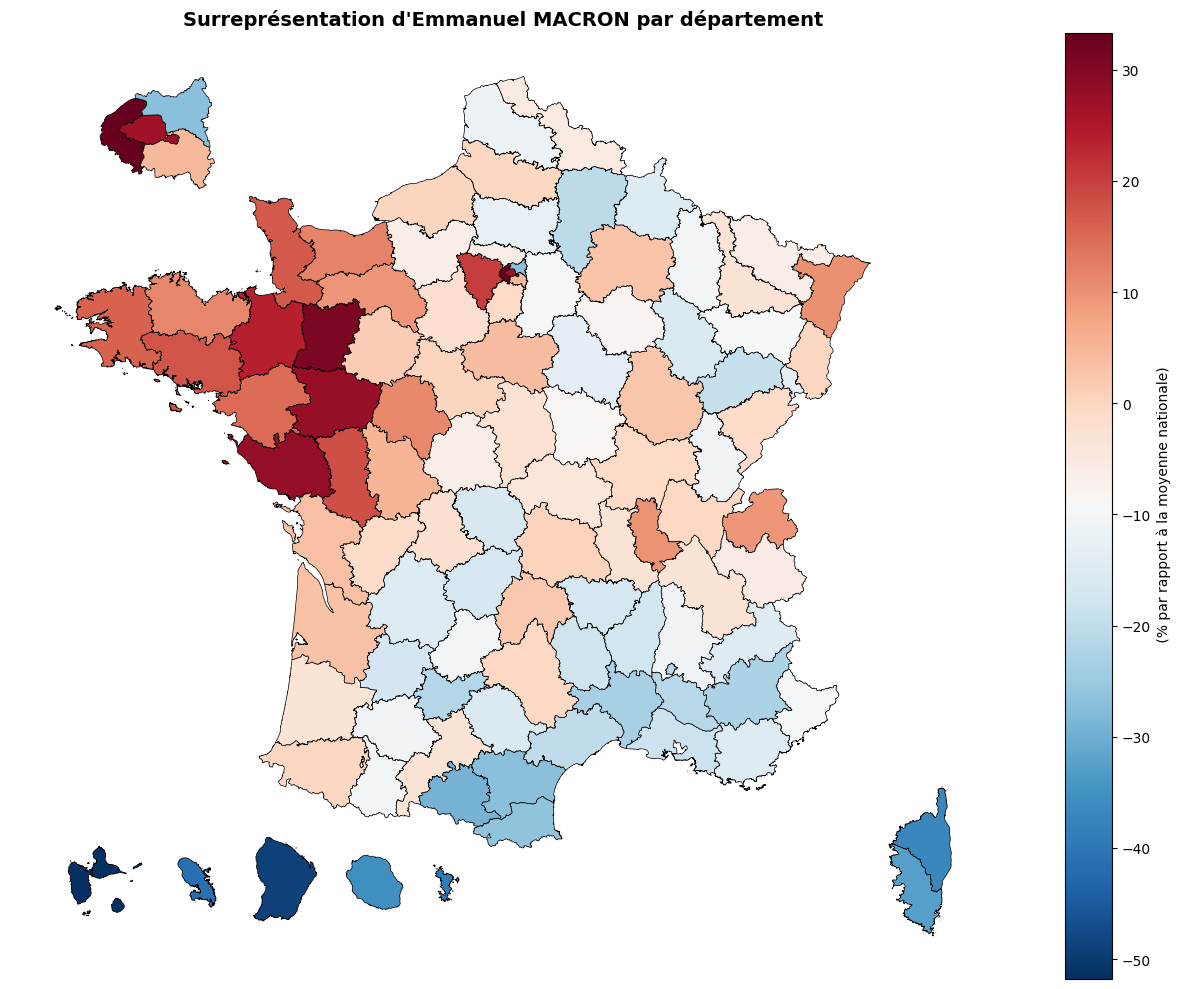

In [39]:
#test sur Emmanuel Macron
macron_data = get_candidate_data('Emmanuel MACRON', score_departements)
macron_map = gdf_departments.merge(
    macron_data,
    left_on='code',
    right_on='code_departement',
    how='left'
)
fig, ax = plt.subplots(figsize=(14, 10))
macron_map.plot(
    column='surrepresentation',
    ax=ax,
    legend=True,
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': ' (% par rapport à la moyenne nationale)', 'orientation': 'vertical'}
)
ax.set_title("Surreprésentation d'Emmanuel MACRON par département", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()